### Plot mediator PT at parton level for Z'

In [1]:
import sys,os,glob,copy
sys.path.append('../')
import numpy as np
from numpy.linalg import norm
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.interpolate import LinearNDInterpolator,interp2d
import matplotlib as mpl
from matplotlib.colors import LogNorm
from IPython.display import display, Markdown
from collections import OrderedDict
import pylhe
import pyslha
import xml.etree.ElementTree as ET


plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set() #Set style
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.cm.get_cmap('RdYlBu')

In [2]:
def readNumEvents(file):
    """
    Moderately efficent way to get the number of events stored in file.
    """
    
    with pylhe._extract_fileobj(file) as fileobj:
        nevts = sum(element.tag == "event" for event, element in ET.iterparse(fileobj, events=["end"]))
    return nevts

In [3]:
inputFiles = {'mxd300' : '../DMSimp_vector_parton_atlas_med/Events/run_01/unweighted_events.lhe.gz',
              'mzd900' : '../DMSimp_vector_parton_atlas_med/Events/run_02/unweighted_events.lhe.gz'}

In [4]:
parameters = {}
for label,file in inputFiles.items():
    banner = list(glob.glob(os.path.dirname(file)+'/*banner.txt'))
    if len(banner) != 1:
        print('%i banner files found for %s!' %(len(banner),label))
        break
    else:
        banner = banner[0]
    xtree = ET.parse(banner)
    xroot = xtree.getroot()
    slha = xroot.find('header').find('slha').text
    pars = pyslha.readSLHA(slha)
    mMed = pars.blocks['MASS'][55]
    mDM = pars.blocks['MASS'][52]
    gVq = pars.blocks['DMINPUTS'][4] # Mediator-quark vector coupling
    gAq = pars.blocks['DMINPUTS'][10] # Mediator-quark axial coupling
    gVx = pars.blocks['DMINPUTS'][2] # Mediator-DM vector coupling
    gAx = pars.blocks['DMINPUTS'][3] # Mediator-DM axial coupling
    brDM = [dec.br for dec in pars.decays[55].decays if sorted(dec.ids) == [-52,52]][0]
    parameters[label] = {'mMed' : mMed, 'mDM' : mDM, 
                         'gVq' : gVq, 'gAq' : gAq, 'gVx' : gVx, 'gAx' : gAx}
    print(label,r': mMed = %1.2f GeV, mDM = %1.2f GeV (BR(Med->DM) = %1.2f)' %(mMed,mDM,brDM))

mxd300 : mMed = 2500.00 GeV, mDM = 300.00 GeV (BR(Med->DM) = 0.47)
mzd900 : mMed = 2500.00 GeV, mDM = 900.00 GeV (BR(Med->DM) = 0.44)


In [5]:
events = {}
nevents = {}
for label,f in inputFiles.items():   
    events[label] = pylhe.read_lhe_with_attributes(f)
    nevents[label] = readNumEvents(f)

In [7]:
## jets
pTj1min = 100.
pTjmin = 25.
etamax = 2.4
## MET
minMET = 250.
## Electrons
pTmin_el = 10.
etamax_el = 2.5
nMax_el = 0
## Muons
pTmin_mu = 10.
etamax_mu = 2.4
nMax_mu = 0

In [8]:
pTj1 = {label : np.array([]) for label in inputFiles}
weights = {label : np.array([]) for label in inputFiles}
met = {label : np.array([]) for label in inputFiles}
njets = {label : np.array([]) for label in inputFiles}
totalweight = {label : 0 for label in inputFiles}

for label,evts in events.items():
   
    nevts = nevents[label]
    parameters[label]['Events'] = nevts
    
    for event in evts:

        particles = event.particles
       
        jets = [p for p in particles if abs(p.id) in [1,2,3,4,5,21] and p.status == 1]
        med = [p for p in particles if abs(p.id) in [55] and p.status == 1]
        electrons = [p for p in particles if abs(p.id) in [11] and p.status == 1]
        muons = [p for p in particles if abs(p.id) in [13] and p.status == 1]
        
            
        weight = event.eventinfo.weight/nevts
        weight = weight*brDM # Include DM BR
        totalweight[label] += weight
            
        # Filter jets
        jetList = []
        for j in jets:
            pT = np.sqrt(j.px**2+j.py**2)
            p = np.sqrt(j.px**2+j.py**2+j.pz**2)
            pL = j.pz
            eta = 0.5*np.log((p+pL)/(p-pL))
            
            if pT < pTjmin:
                continue
            if np.abs(eta) > etamax:
                continue
            jetList.append(j)
        jetList = sorted(jetList, key = lambda j: np.sqrt(j.px**2+j.py**2), reverse=True)          
        
            
        # Filter electrons
        electronList = []
        for el in electrons:
            pT = np.sqrt(el.px**2+el.py**2)
            p = np.sqrt(el.px**2+el.py**2+el.pz**2)
            pL = el.pz
            eta = 0.5*np.log((p+pL)/(p-pL))
            
            if pT < pTmin_el:
                continue
            if np.abs(eta) > etamax_el:
                continue
            electronList.append(el)
        electronList = sorted(electronList, key = lambda j: np.sqrt(j.px**2+j.py**2), reverse=True)                                    
        
        # Filter muons
        muonList = []
        for mu in muons:
            pT = np.sqrt(mu.px**2+mu.py**2)
            p = np.sqrt(mu.px**2+mu.py**2+mu.pz**2)
            pL = mu.pz
            eta = 0.5*np.log((p+pL)/(p-pL))
            
            if pT < pTmin_mu:
                continue
            if np.abs(eta) > etamax_mu:
                continue
            muonList.append(mu)
        muonList = sorted(muonList, key = lambda j: np.sqrt(j.px**2+j.py**2), reverse=True)                                            
              
        # Compute MET
        MET = np.sqrt(med[0].px**2 + med[0].py**2)
        
        # Compute deltaPhi
        if len(jetList) > 0:
            phij1 = np.arctan2(jetList[0].py,jetList[0].px)
            phiMET = np.arctan2(med[0].py,med[0].px)
            deltaPhi = np.abs(phij1-phiMET)
        else:
            deltaPhi = 0.0
        
        #Apply cuts:
        if len(electronList) > 0:
            continue
        if len(muonList) > 0:
            continue
        if len(jetList) == 0:
            continue
        
        pT1 = np.sqrt(jetList[0].px**2+jetList[0].py**2)
        if MET < minMET:
            continue
        if pT1 < pTj1min:
            continue
        if deltaPhi < 0.5:
            continue
        
        # Store relevant data        
        njets[label] = np.append(njets[label],len(jets))
        pTj1[label] = np.append(pTj1[label],pT1)
        weights[label] = np.append(weights[label],weight)
        met[label] = np.append(met[label],MET)

In [9]:
for label,w in totalweight.items():
    print(label,'total cross-section = %1.3e pb' %(w))
colors = {label : sns.color_palette('deep')[i+1] for i,label in enumerate(weights.keys())}   

mxd300 total cross-section = 5.084e-02 pb
mzd900 total cross-section = 5.091e-02 pb


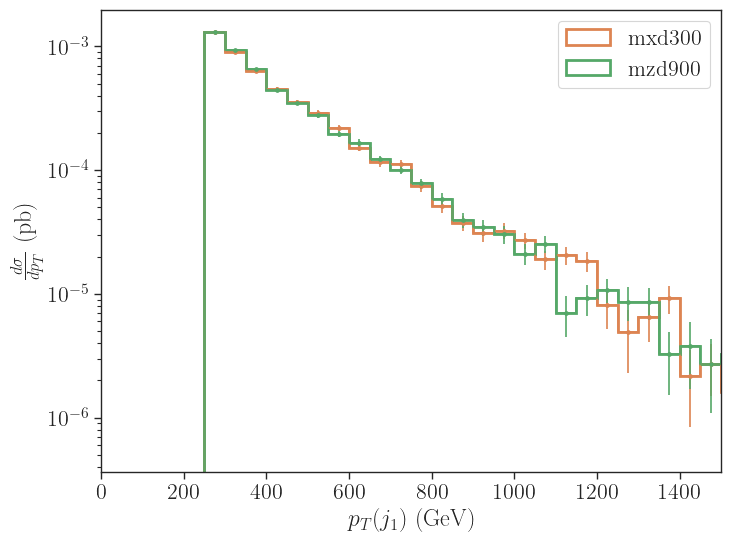

In [12]:
fig = plt.figure(figsize=(8,6))
for label,pt in pTj1.items():
    binc,binEdges,patches = plt.hist(pt,bins=np.linspace(0,5000,101),
                               label=label,histtype='step',color=colors[label],
                               weights=weights[label],linewidth=2)
    errorc2,_ = np.histogram(pt,bins=binEdges,weights=weights[label]**2)
    errorc = np.sqrt(errorc2)
    binCenter = (binEdges[0:-1]+binEdges[1:])/2.
    plt.errorbar(binCenter,binc,yerr = errorc, marker = '.', 
                 drawstyle = 'steps-mid',color=colors[label])

    
plt.yscale('log')
# plt.ylim(1e-3,1)
plt.xlabel(r'$p_T(j_1)$ (GeV)')
plt.ylabel(r'$\frac{d\sigma}{dp_{T}}$ (pb)')
plt.xlim(0,1500)
plt.legend()
plt.show()

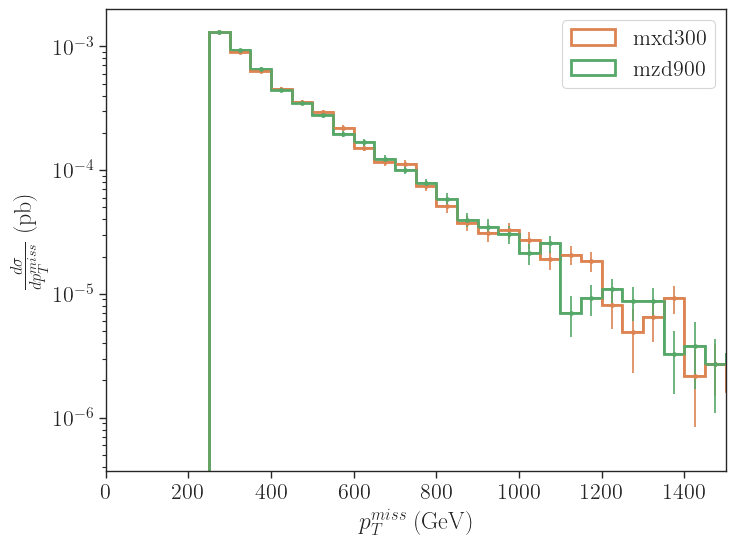

In [14]:
fig = plt.figure(figsize=(8,6))
for label,metPts in met.items():
    binc,binEdges,patches = plt.hist(metPts,bins=np.linspace(0,5000,101),
                               label=label,histtype='step',color=colors[label],
                               weights=weights[label],linewidth=2)
    errorc2,_ = np.histogram(metPts,bins=binEdges,weights=weights[label]**2)
    errorc = np.sqrt(errorc2)
    binCenter = (binEdges[0:-1]+binEdges[1:])/2.
    plt.errorbar(binCenter,binc,yerr = errorc, marker = '.', 
                 drawstyle = 'steps-mid',color=colors[label])

    
plt.yscale('log')
# plt.ylim(1e-3,1e-2)
plt.xlabel(r'$p_T^{miss}$ (GeV)')
plt.ylabel(r'$\frac{d\sigma}{d p_T^{miss}}$ (pb)')
plt.xlim(0,1500)
plt.legend()
plt.show()